In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vafaeii/kth-action-recognition-dataset")

print("Path to dataset files:", path)

100%|█████████████████████████████████████████████████████████████████████████████| 1.07G/1.07G [08:20<00:00, 2.30MB/s]

Extracting files...


Path to dataset files: C:\Users\Abhishek\.cache\kagglehub\datasets\vafaeii\kth-action-recognition-dataset\versions\37


In [1]:
path_to_dir = 'C:\\Users\\Abhishek\\.cache\\kagglehub\\datasets\\vafaeii\\kth-action-recognition-dataset\\versions\\35\\'

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 as cv

In [3]:
os.listdir(path_to_dir)

['00sequences.txt',
 'boxing',
 'handclapping',
 'handwaving',
 'jogging',
 'running',
 'walking']

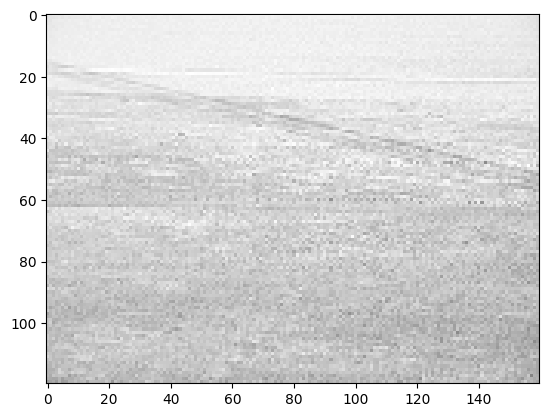

In [4]:
x = np.random.randint(1,7)
topic = os.listdir(path_to_dir)[x]
len(os.listdir(path_to_dir +topic))
ind = np.random.randint(0,99)
path_2 = os.listdir(path_to_dir +topic)[ind]

video_path = path_to_dir + topic + '\\' + path_2

video =cv.VideoCapture(video_path)
_,frame= video.read()
frame_rgb = cv.cvtColor(frame, cv.COLOR_BGR2RGB)
plt.imshow(frame_rgb)

In [5]:
frame.shape

(120, 160, 3)

In [6]:
video.get(cv.CAP_PROP_FRAME_COUNT)

550.0

In [7]:
frame_per_vid = 16

In [8]:
#prepping data now

In [9]:
classes = os.listdir(path_to_dir)[1:]
classes

['boxing', 'handclapping', 'handwaving', 'jogging', 'running', 'walking']

In [10]:
height = 120
width = 160

In [11]:
def load_video_as_clip(video_path,frame_per_vid = 32, target_size=(120,160)):
    cap = cv.VideoCapture(video_path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv.resize(frame, target_size[::-1])   
        frame = cv.cvtColor(frame, cv.COLOR_BGR2RGB)
        frames.append(frame)
    cap.release()
    frames = np.array(frames)          
    if len(frames) == 0:
        return None
        
    idx = np.linspace(0, len(frames)-1, frame_per_vid).astype(int)
    clip = frames[idx]            
    return clip

In [12]:
clips = []
labels = []

In [13]:
for class_idx, cls in enumerate(classes):
    class_dir = os.path.join(path_to_dir, cls)
    for fname in os.listdir(class_dir):
        if not fname.lower().endswith(('.avi', '.mp4', '.mpeg')):
            continue
        vpath = os.path.join(class_dir, fname)
        clip = load_video_as_clip(vpath, frame_per_vid=32, target_size=(height, width))
        if clip is None:
            continue
        clips.append(clip)
        labels.append(class_idx)

In [14]:
clips  = np.array(clips, dtype=np.uint8)       
labels = np.array(labels, dtype=np.int64)

print('clips:', clips.shape, 'labels:', labels.shape)

clips: (599, 32, 120, 160, 3) labels: (599,)


In [15]:
from sklearn.model_selection import train_test_split

In [16]:
xtr, xts, ytr, yts = train_test_split( clips, labels, test_size=0.2, random_state=11, stratify=labels)

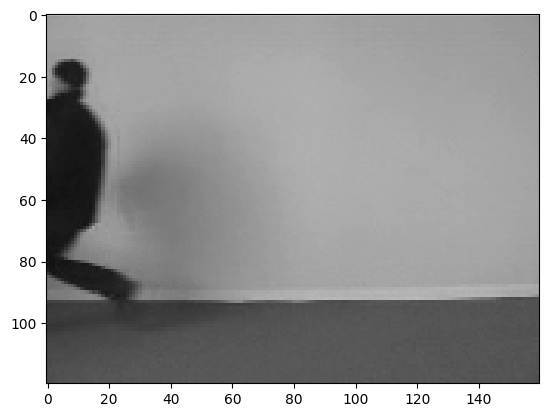

In [17]:
plt.imshow(xtr[0][5])

In [18]:
xts.shape

(120, 32, 120, 160, 3)

In [19]:
ytr.shape

(479,)

In [20]:
xtr_scaled = xtr/255.0
xts_scaled = xts/255.0

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, GRU, Dense, MaxPool2D, GlobalAveragePooling2D, Dropout, Input, TimeDistributed, BatchNormalization, Activation, Bidirectional

C:\Users\Abhishek\tf-env\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [22]:
video_classifier = Sequential()

video_classifier.add(Input([32,120,160,3]))
video_classifier.add(TimeDistributed(Conv2D(filters=32, kernel_size=(3,3), padding='same')))
video_classifier.add(TimeDistributed(MaxPool2D()))
video_classifier.add(TimeDistributed(BatchNormalization()))
video_classifier.add(TimeDistributed(Activation('relu')))
video_classifier.add(TimeDistributed(Conv2D(filters=64, kernel_size=(3,3), padding='same')))
video_classifier.add(TimeDistributed(MaxPool2D()))
video_classifier.add(TimeDistributed(BatchNormalization()))
video_classifier.add(TimeDistributed(Activation('relu')))
video_classifier.add(TimeDistributed(Conv2D(filters=128, kernel_size=(3,3), padding='same')))
video_classifier.add(TimeDistributed(MaxPool2D()))
video_classifier.add(TimeDistributed(BatchNormalization()))
video_classifier.add(TimeDistributed(Activation('relu')))
video_classifier.add(TimeDistributed(Conv2D(filters=256, kernel_size=(3,3), padding='same')))
video_classifier.add(TimeDistributed(GlobalAveragePooling2D()))

video_classifier.add(Bidirectional(GRU(128, return_sequences=False, recurrent_dropout=0.1, recurrent_initializer='glorot_uniform')))

video_classifier.add(Dense(256, activation='relu'))
video_classifier.add(Dropout(0.3))
video_classifier.add(Dense(128, activation='relu'))
video_classifier.add(Dense(6, activation='softmax'))

video_classifier.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [23]:
video_classifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ time_distributed (TimeDistributed)   │ (None, 32, 120, 160, 32)    │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_1 (TimeDistributed) │ (None, 32, 60, 80, 32)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_2 (TimeDistributed) │ (None, 32, 60, 80, 32)      │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_3 (TimeDistributed) │ (None, 32, 60, 80, 32)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_4 (TimeDistributed) │ (None, 32, 60, 80, 64)      │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_5 (TimeDistributed) │ (None, 32, 30, 40, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_6 (TimeDistributed) │ (None, 32, 30, 40, 64)      │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_7 (TimeDistributed) │ (None, 32, 30, 40, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_8 (TimeDistributed) │ (None, 32, 30, 40, 128)     │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_9 (TimeDistributed) │ (None, 32, 15, 20, 128)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_10                  │ (None, 32, 15, 20, 128)     │             512 │
│ (TimeDistributed)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_11                  │ (None, 32, 15, 20, 128)     │               0 │
│ (TimeDistributed)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_12                  │ (None, 32, 15, 20, 256)     │         295,168 │
│ (TimeDistributed)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_13                  │ (None, 32, 256)             │               0 │
│ (TimeDistributed)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 256)                 │         296,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴──────────────

 Total params: 785,222 (3.00 MB)

 Trainable params: 784,774 (2.99 MB)

 Non-trainable params: 448 (1.75 KB)

In [24]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [25]:
early_stop = EarlyStopping(mode='min', patience=15, restore_best_weights=True)

In [26]:
reduce_lr = ReduceLROnPlateau(patience=15,mode='min')

In [27]:
video_classifier.fit(xtr,ytr, validation_data=(xts,yts), epochs=2000, callbacks=[early_stop, reduce_lr], batch_size=6)

Epoch 1/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 516s 5s/step - accuracy: 0.2484 - loss: 1.7386 - val_accuracy: 0.2667 - val_loss: 1.7072 - learning_rate: 0.0010
Epoch 2/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 404s 5s/step - accuracy: 0.2735 - loss: 1.3673 - val_accuracy: 0.2917 - val_loss: 1.2018 - learning_rate: 0.0010
Epoch 3/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 421s 5s/step - accuracy: 0.3445 - loss: 1.2592 - val_accuracy: 0.3333 - val_loss: 1.1749 - learning_rate: 0.0010
Epoch 4/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 427s 5s/step - accuracy: 0.3048 - loss: 1.2357 - val_accuracy: 0.2750 - val_loss: 1.5220 - learning_rate: 0.0010
Epoch 5/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 415s 5s/step - accuracy: 0.3340 - loss: 1.1726 - val_accuracy: 0.3333 - val_loss: 1.1247 - learning_rate: 0.0010
Epoch 6/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 422s 5s/step - accuracy: 0.3278 - loss: 1.1804 - val_accuracy: 0.3917 - val_loss: 1.0913 - learning_rate: 0.0010
Epoch 7/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 428s 5s/step - accuracy: 0.3570 - loss: 1.

In [28]:
video_classifier.save('vid_class.keras')

In [29]:
metrics = pd.DataFrame(video_classifier.history.history)

<Axes: >

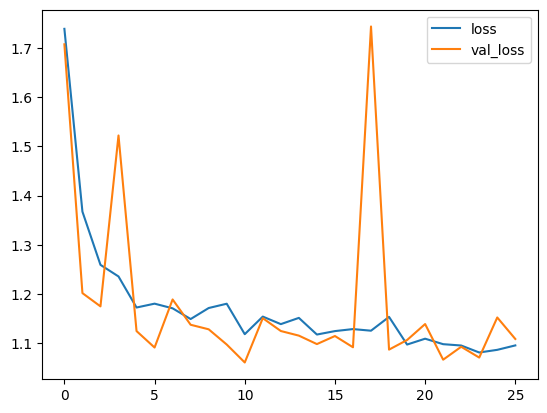

In [30]:
metrics[['loss', 'val_loss']].plot()

<Axes: >

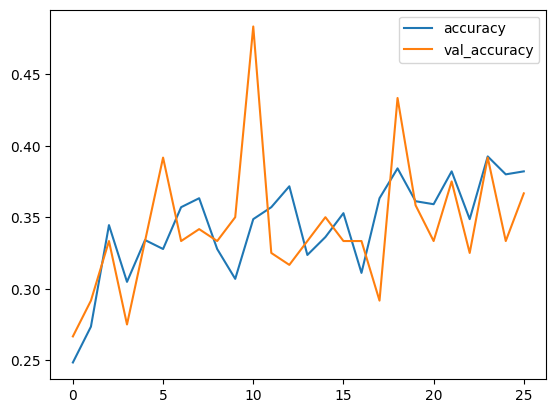

In [31]:
metrics[['accuracy', 'val_accuracy']].plot()

In [32]:
video_classifier.evaluate(xts,yts)

4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.4833 - loss: 1.0609


[1.0609370470046997, 0.4833333194255829]

In [33]:
pred= video_classifier.predict(xts)

4/4 ━━━━━━━━━━━━━━━━━━━━ 32s 6s/step


In [35]:
pred = np.argmax(pred, axis=-1)

In [36]:
pred

array([4, 1, 4, 1, 4, 1, 4, 5, 5, 1, 4, 1, 1, 5, 4, 1, 1, 1, 3, 4, 5, 1,
       4, 5, 1, 5, 5, 1, 1, 1, 1, 1, 1, 5, 4, 4, 4, 4, 1, 1, 1, 1, 3, 4,
       1, 1, 5, 1, 5, 1, 3, 1, 1, 3, 1, 3, 5, 3, 4, 1, 4, 3, 1, 1, 1, 4,
       1, 1, 5, 1, 1, 4, 5, 1, 1, 5, 1, 1, 5, 4, 1, 4, 1, 4, 1, 4, 1, 1,
       4, 5, 1, 1, 1, 1, 5, 5, 1, 1, 1, 5, 3, 3, 5, 5, 3, 1, 5, 1, 1, 4,
       5, 1, 1, 1, 4, 1, 5, 1, 4, 3])

In [37]:
yts

array([3, 0, 3, 2, 3, 1, 3, 3, 5, 2, 4, 0, 2, 5, 4, 1, 1, 0, 5, 4, 5, 2,
       4, 5, 0, 5, 5, 0, 1, 2, 2, 1, 0, 3, 4, 4, 4, 3, 1, 0, 1, 2, 3, 4,
       1, 2, 3, 1, 4, 1, 4, 1, 2, 3, 1, 5, 5, 5, 5, 0, 3, 3, 0, 2, 2, 3,
       0, 2, 3, 0, 0, 4, 5, 1, 1, 5, 0, 0, 5, 4, 1, 3, 0, 4, 0, 4, 2, 2,
       4, 5, 1, 0, 1, 1, 4, 5, 2, 1, 2, 3, 3, 3, 5, 5, 3, 2, 5, 2, 0, 4,
       3, 0, 2, 0, 4, 2, 5, 1, 4, 4])

In [39]:
from sklearn.metrics import classification_report, confusion_matrix

<Axes: >

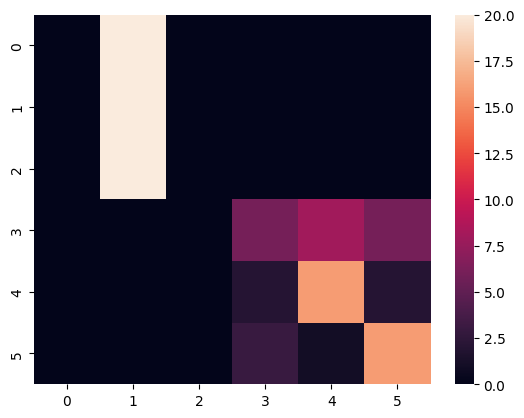

In [40]:
sns.heatmap(confusion_matrix(yts,pred))

In [41]:
print(classification_report(yts,pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1       0.33      1.00      0.50        20
           2       0.00      0.00      0.00        20
           3       0.55      0.30      0.39        20
           4       0.64      0.80      0.71        20
           5       0.67      0.80      0.73        20

    accuracy                           0.48       120
   macro avg       0.36      0.48      0.39       120
weighted avg       0.36      0.48      0.39       120



C:\Users\Abhishek\tf-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Abhishek\tf-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Abhishek\tf-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
